This code visualizes neuron activations for an actual forward pass, with down proj vectors scaled on a given Fourier plane.

For whatever tasks you want to visualize, you must run `python src/cache_neuron_activations.py --tasks weekdays months hours addition --layer 18`

In [1]:
import torch 
from nnsight import LanguageModel 
model = LanguageModel("meta-llama/Llama-3.1-8B", dispatch=True, device_map="cuda")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [5]:
import matplotlib.pyplot as plt 

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 16

In [ ]:
# func to load in mlp_output Fourier probes for sum_ab 
import os 

PROBES_DIR = "fourier_probes/addition_probes_layer_18_last_token_resid/"

def load_output_probe(period, func_name):
    path = os.path.join(PROBES_DIR, f"probe_period{period}_{func_name}.pt")
    sd = torch.load(path, map_location="cpu", weights_only=True)
    return sd["linear.weight"].squeeze(0)  # (4096,)

In [7]:
# based on results from neurons_across_sums.ipynb
neurons_by_mod = {
    "mod_2" : [1712, 10297], # mod 2 
    "mod_5" : [8859, 8887, 3896, 2404, 12728, 13492], # mod 5
    "mod_10" : [8409, 3644, 2955, 251, 11029, 10099, 12154, 11545], # mod 10 
    "mod_20" : [5700, 3650, 13003], # mod 20 
    "mod_50" : [12778, 6339, 8343, 61, 1448, 1768, 2372],  # mod 50
    "mod_100" : [6721, 11096] # mod 100 
}

In [10]:
# plot the neuron activations for a specific forward pass 
import numpy as np 
import torch 
from tasks import TASKS

# specify the mod 
T = 5
NEURONS = neurons_by_mod[f"mod_{T}"]
if T == 2:
    colors = [plt.cm.RdBu(0.8), plt.cm.RdBu(0.2)]
else:
    colors = plt.cm.tab10(np.linspace(0, 1, len(NEURONS)))

# load in probes 
w_cos_out = load_output_probe(T, "cos")
w_sin_out = load_output_probe(T, "sin")
d_cos_out = (w_cos_out / w_cos_out.norm()).bfloat16()
d_sin_out = (w_sin_out / w_sin_out.norm()).bfloat16()
print(f"mlp_output sum_ab probes: cos·sin = {(d_cos_out @ d_sin_out).item():.4f}")

W_down = model.model.layers[18].mlp.down_proj.weight.detach().cpu() # (4096, 14336)
down_projections = {}  # down_projections[neuron] = (cos_coord, sin_coord)
for n in NEURONS:
    w_n = W_down[:, n]  # (4096,)
    c = (w_n @ d_cos_out).item()
    s = (w_n @ d_sin_out).item()
    down_projections[n] = (c, s)

mlp_output sum_ab probes: cos·sin = -0.0247


prompt: 18 four
8859 -1.9375
8887 0.1044921875
3896 -0.5234375
2404 -0.9375
12728 -6.03125
13492 1.09375
[-1.35763168  1.21748495]


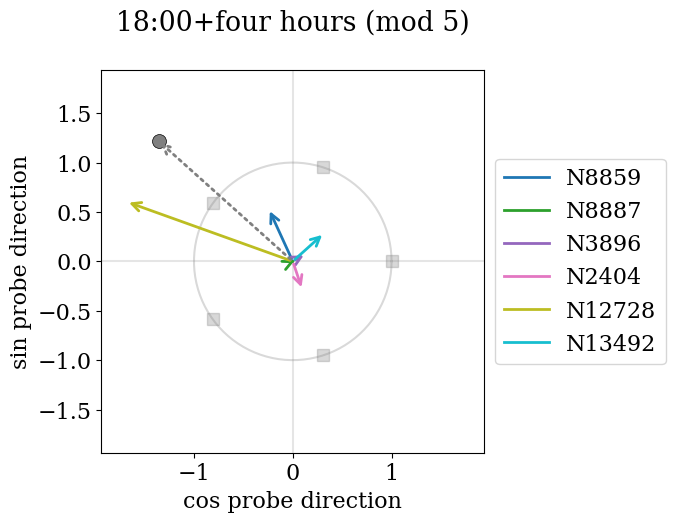

In [11]:
# specify the task
task = "hours"
cm = TASKS[task]["causal_model"]
inps = cm.values["input"]
nums = cm.values["offset"]
both_mlp_acts = torch.load(f"../outputs/neuron_activations/Llama-3.1-8B/{task}_L18/both_mlp_acts.pt") # (48, 24, 14336)

# specify the prompt 
inp_idx = 18
num_idx = 3
inp = inps[inp_idx]
num = nums[num_idx]

print("prompt:", inp, num)

fig, ax = plt.subplots(figsize=(7, 7))

end_sum = np.zeros(shape=(2,))
arrows = []
for i, n in enumerate(NEURONS):
    activation = both_mlp_acts[num_idx, inp_idx, n].item()
    c, s = down_projections[n]
    c *= activation 
    s *= activation
    end_sum[0] += c
    end_sum[1] += s
    arrows.append((c, s))

    print(n, activation)
    
    ax.annotate('', xy=(c, s), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))
    ax.plot([], [], color=colors[i], lw=2, label=f'N{n}') 
    
    angle = np.arctan2(s, c)
    residue = (angle / (2 * np.pi / T)) % T

print(end_sum)

ax.annotate('', xy=(end_sum[0], end_sum[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color="gray", lw=2, linestyle='dotted'))
ax.plot(end_sum[0], end_sum[1], 'o', color="gray", markersize=10,
        markeredgecolor='k', markeredgewidth=0.5)


# fixed unit circle
r_ref = 1.0

theta = np.linspace(0, 2*np.pi, 100)
ax.plot(r_ref*np.cos(theta), r_ref*np.sin(theta), 'k-', alpha=0.15)
for r in range(T):
    angle = 2 * np.pi * r / T
    ax.plot(r_ref*np.cos(angle), r_ref*np.sin(angle),
            's', color='gray', alpha=0.3, markersize=8)

# set axis limits to fit both the unit circle and all arrows
all_coords = [c for c, s in arrows] + [s for c, s in arrows] + [end_sum[0], end_sum[1]]
lim = max(max(abs(v) for v in all_coords), r_ref) * 1.15
# lim = 1.85
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.axhline(0, color='gray', alpha=0.2)
ax.axvline(0, color='gray', alpha=0.2)
ax.set_aspect('equal')
ax.set_xlabel('cos probe direction')
ax.set_ylabel('sin probe direction')
if task == "hours":
    ax.set_title(f'{inp}:00+{num} hours (mod {T})\n')
else: 
    ax.set_title(f"{inp} + {num} (mod {T})\n")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()